In [1]:
!hostname

node114


In [2]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from src import util_analysis 
from src import util_process_prolific as util_process
import re

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Get participant data for current pipeline

In [3]:
def get_target_transcript(fname):
    return df_w_transcripts.loc[df_w_transcripts['targ_src_stem'].eq(fname), 'target_transcripts'].values[0]

def get_distractor_tscript(fname):
    if df_w_transcripts['dist_1_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_1_src_stem'].eq(fname), 'distractor_1_transcripts'].values[0]
    elif df_w_transcripts['dist_2_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_2_src_stem'].eq(fname), 'distractor_2_transcripts'].values[0]
    return tscript

def get_part_manifest_dict(manifest_file_name):
    part_manifest = pd.read_pickle(manifest_file_name)
    records = []
    trial_ix_count = 0 
    for block_name, block in part_manifest.items():
        for trial_ix, trial_dict in block.items():
            trial_dict['trial_num'] = trial_ix_count
            trial_dict['target_azimuth'] = trial_dict['target_loc'][0] 
            trial_dict['target_elev'] = trial_dict['target_loc'][1]
            trial_dict['distractor_azimuth'] = trial_dict['distractor_loc'][0]
            trial_dict['distractor_elev'] = trial_dict['distractor_loc'][1]
            trial_dict['block_name'] = block_name
            records.append(trial_dict)
            trial_ix_count += 1
    manifest_df = pd.DataFrame(records)
    manifest_df.drop(columns=['target_loc', 'distractor_loc', 'distractor_word'], inplace=True)
    return manifest_df

In [4]:
#### Load in experiment manifests with full transcripts
parent_dir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
manifest = pd.read_pickle(parent_dir / "full_cue_target_distractor_df_w_meta_paths.pdpkl")

path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(util_process.unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(util_process.slice_transcript_path)


In [5]:


# Add elev delta trials 
result_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v00/'
exp_manifest_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/spotlight_v00/'
part_results = sorted(list(Path(result_path).glob('*.csv')))
meta_files = sorted(list(Path(exp_manifest_path).glob('*meta.pkl')))
# results += results
# manifests += manifests

# meta_files
manifest_dict = {}
for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    manifest_dict[part_name] = meta_file

dfs = []
for result_file in part_results:
    if '20' in result_file.stem:
        continue
    part_name = result_file.stem
    # remove space 
    if 'pilot' in result_file.parent.stem:
        part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
    if ' ' in part_name:
        part_name = part_name.split(' ')[0]
    # get digits in string pattern participant_xxx_ or participant_XXX.
    if 'test' not in part_name: 
        part_ix = int(re.search(r'\d+', part_name).group())
        part_name_str = f"participant_{part_ix:03d}"
    manifest_file = manifest_dict[part_name_str]
    part_df = util_process.get_part_df(result_file)
    manifest_df = get_part_manifest_dict(manifest_file)
    # merge on shared trial_index
    part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            manifest_df, left_on='trial_num', right_on='trial_num',)
    part_df['participant'] = part_name_str
    dfs.append(part_df)

results_df = pd.concat(dfs, ignore_index=True)
results_df['abs_target_azim'] = results_df.target_azimuth.abs()
# results_df['dist_1_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_1_fn.to_list()]
# results_df['dist_2_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_2_fn.to_list()]
# results_df['target_transcripts'] = [util_process.get_target_transcript(fname, df_w_transcripts) for fname in results_df.src_fn.to_list()]



In [ ]:
results_df.groupby(['participant'])

,trial_num,response,correct_response,correct,azim_delta,elev_delta,snr,target_word,target_azimuth,target_elev,distractor_azimuth,distractor_elev,block_name,participant,abs_target_azim
0,0,regular,regular,1.0,10,0,0,regular,0,0,-10,0,block_front,participant_000,0
1,1,program,program,1.0,30,0,0,program,0,0,-30,0,block_front,participant_000,0
2,2,before,famous,0.0,90,0,0,famous,0,0,-90,0,block_front,participant_000,0
3,3,within,within,1.0,0,0,0,within,0,0,0,0,block_front,participant_000,0
4,4,appeared,appear,0.0,90,0,0,appear,0,0,-90,0,block_front,participant_000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557,238,family,family,1.0,10,0,0,family,0,0,10,0,block_ninety,participant_001,0
558,239,company,company,1.0,30,0,0,company,0,0,30,0,block_ninety,participant_001,0
559,0,being,current,0.0,0,0,0,current,0,0,0,0,block_front,participant_001,0
560,1,looked,looked,1.0,10,0,0,looked,0,0,10,0,block_front,participant_001,0


In [7]:
results_df['computed_azim_delta'] = np.abs(results_df['distractor_azimuth'] - results_df['target_azimuth'])

In [8]:
results_df[results_df['computed_azim_delta'] != results_df['azim_delta']]

,trial_num,response,correct_response,correct,azim_delta,elev_delta,snr,target_word,target_azimuth,target_elev,distractor_azimuth,distractor_elev,block_name,participant,abs_target_azim,computed_azim_delta


In [13]:
# group data 

results_summary = results_df.groupby(['participant', 'block_name', 'azim_delta']).agg({'correct': ['mean', 'count']}).reset_index()

In [15]:
# results_summary

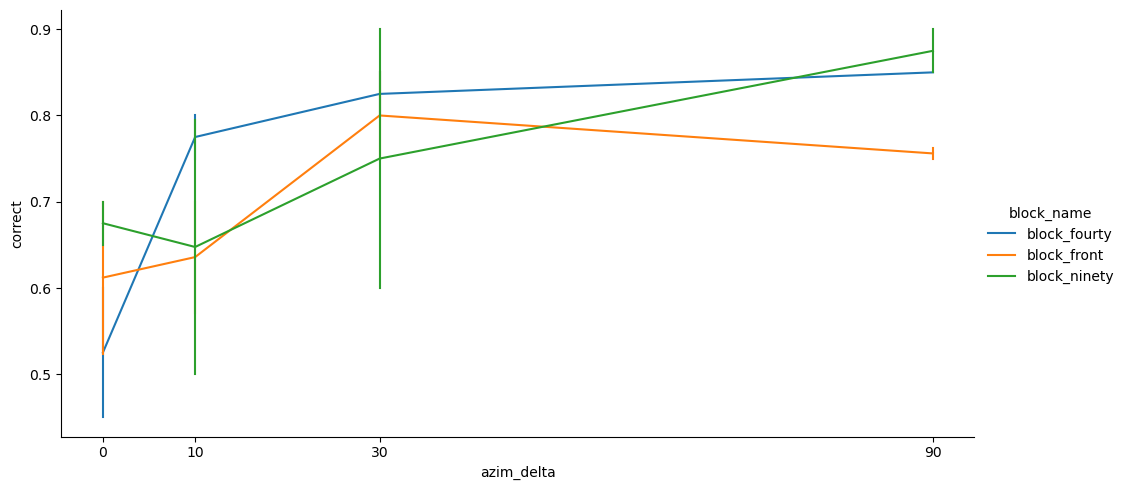

In [11]:
g = sns.relplot(data=results_summary, x='azim_delta', y='correct', hue='block_name',
                 errorbar=('se', 1),err_style='bars',
                  kind='line', aspect=2)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique())